****
**1. Install Required Libraries**
****

In [ ]:
!pip install tensorflow matplotlib scikit-learn


****
**2. Mount Google Drive**
****

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


****
**3. Define Dataset Paths**
****

In [ ]:
TRAIN_DIR = '/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/train'
TEST_DIR  = '/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/test'
VAL_DIR   = '/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/val'

****
**4. Verify Dataset Structure**
****

In [ ]:
import os
print(os.path.exists(TRAIN_DIR))
print(os.path.exists(TEST_DIR))
print(os.listdir(TRAIN_DIR))

True
True
['NORMAL', 'PNEUMONIA']


****
**5. Create a Sample Dataset of (200, 500, 700, 1000) Images**
****

In [ ]:

import os
import shutil
import random

DATASET_SIZE = 500   # Change to 200, 500, 700, 1000 later

SOURCE_TRAIN = "/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/train"
TARGET = "/content/sample_dataset"

if os.path.exists(TARGET):
    shutil.rmtree(TARGET)

os.makedirs(f"{TARGET}/NORMAL")
os.makedirs(f"{TARGET}/PNEUMONIA")

normal_count = DATASET_SIZE // 2
pneumonia_count = DATASET_SIZE // 2

normal_images = os.listdir(f"{SOURCE_TRAIN}/NORMAL")
pneumonia_images = os.listdir(f"{SOURCE_TRAIN}/PNEUMONIA")

selected_normal = random.sample(normal_images, normal_count)
selected_pneumonia = random.sample(pneumonia_images, pneumonia_count)

for img in selected_normal:
    shutil.copy(
        f"{SOURCE_TRAIN}/NORMAL/{img}",
        f"{TARGET}/NORMAL/{img}"
    )

for img in selected_pneumonia:
    shutil.copy(
        f"{SOURCE_TRAIN}/PNEUMONIA/{img}",
        f"{TARGET}/PNEUMONIA/{img}"
    )

print(f"Dataset created with {DATASET_SIZE} images")

Dataset created with 1000 images


****
**6. Verify Sample Dataset**
****


In [ ]:
import os

print("NORMAL:", len(os.listdir("/content/sample_dataset/NORMAL")))
print("PNEUMONIA:", len(os.listdir("/content/sample_dataset/PNEUMONIA")))

NORMAL: 500
PNEUMONIA: 500


****
**7. Load Dataset**
****


In [ ]:
import tensorflow as tf

IMG_SIZE = (224,224)
BATCH_SIZE = 8

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/sample_dataset",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/sample_dataset",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


****
**Check Dataset Size**
****

In [ ]:
print("Training batches:", len(train_ds))
print("Testing batches:", len(test_ds))

Training batches: 100
Testing batches: 25


****
**9. Build CNN Model**
****


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255),

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(1,activation='sigmoid')
])

****
**10. Compile Model**
****


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully")

Model compiled successfully


In [ ]:

import time

start_time = time.time()


****
**11. Train Model**
****


In [ ]:

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

end_time = time.time()

training_time = end_time - start_time

print("Training Time:", training_time, "seconds")



Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.6550 - loss: 0.6436 - val_accuracy: 0.8100 - val_loss: 0.5467
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 79s 996ms/step - accuracy: 0.8325 - loss: 0.5104 - val_accuracy: 0.8000 - val_loss: 0.6762
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8525 - loss: 0.4430 - val_accuracy: 0.8000 - val_loss: 0.5905
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 997ms/step - accuracy: 0.8650 - loss: 0.3836 - val_accuracy: 0.8100 - val_loss: 0.4402
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9000 - loss: 0.3669 - val_accuracy: 0.8500 - val_loss: 0.3967
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.9250 - loss: 0.1954 - val_accuracy: 0.9000 - val_loss: 0.2419
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.9500 - loss: 0.1691 - val_accuracy: 0.9200 - val_loss: 0.2500
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.9675 - loss: 0.0864 - val_accuracy: 0.9100 - val

****
**12. Evaluate Model**
****


In [ ]:

loss, accuracy = model.evaluate(test_ds)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

print("\n----- RESULTS -----")
print("Model Name: CNN")
print("Dataset Size:", DATASET_SIZE)
print("Training Time:", round(training_time,2), "seconds")
print("Accuracy:", round(accuracy,4))
print("Loss:", round(loss,4))


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.9200 - loss: 0.2710
Test Loss: 0.27096179127693176
Test Accuracy: 0.9200000166893005

----- RESULTS -----
Model Name: CNN
Dataset Size: 500
Training Time: 652.1 seconds
Accuracy: 0.92
Loss: 0.271


****
**13. Accuracy Graph**
****


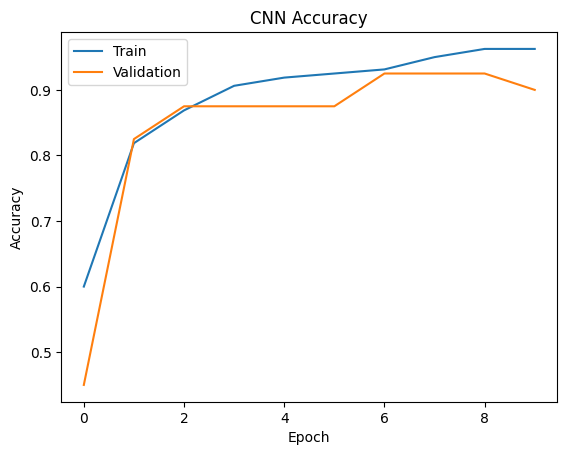

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('CNN Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

****
**14. Loss Graph**
****

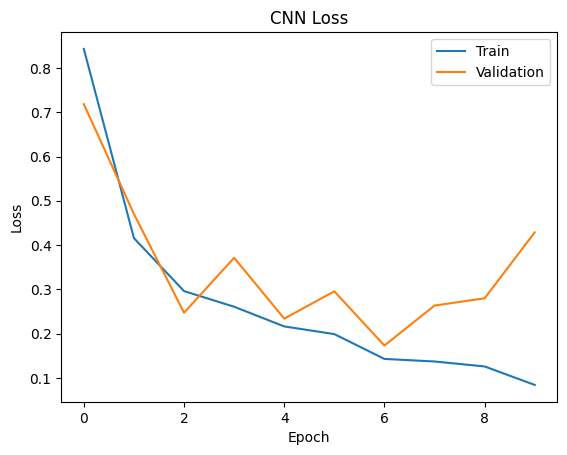

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

****
**15. Save the Model**
****

In [ ]:
model.save('cnn_pneumonia_model.h5')